# 🩺 Diabetes Prediction - End-to-End Machine Learning Project

Author: Mythili P

Dataset: Pima Indians Diabetes Database (Kaggle)

Type: Binary Classification

Tools: Python · Pandas · Scikit-learn · XGBoost · Seaborn · Matplotlib

# 📌 Problem Statement
Diabetes is a chronic disease affecting millions worldwide. Early detection is critical for timely medical intervention. This project builds a machine learning pipeline to predict whether a patient is diabetic based on diagnostic measurements such as glucose level, BMI, age, and insulin.

Target Variable: Outcome — 0 (No Diabetes) · 1 (Diabetes)

# 📁 Table of Contents


1.   Import Libraries
2.   Load & Understand Data
3.   Exploratory Data Analysis (EDA)
4.   Data Preprocessing
5.   Model Building & Evaluation
6.   Hyperparameter Tuning
7.   Model Comparison
8.   Feature Importance & Interpretation
9.   Key Takeaways & Business Insights
10.   Model Saving









# 1. 📦 Import Libraries


We import all required libraries upfront. Explicit imports (no wildcards) are best practice for production-quality code — they make dependencies transparent and avoid namespace collisions.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 📊 Load & Understand Data
We load the dataset and run basic checks to understand shape, data types, and get a first look at the data.

In [6]:
import os
# Works on both Google Colab and local/GitHub
if os.path.exists('/content/diabetes.csv'):
    df = pd.read_csv('/content/diabetes.csv')   # Google Colab
else:
    df = pd.read_csv('diabetes.csv')             # Local / anyone else

***BASIC CHECKS***

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [9]:
df.shape

(768, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


***📝 Observation from describe():***

*   Several columns show minimum value of 0 which is biologically impossible:

Glucose = 0, BloodPressure = 0, SkinThickness = 0, Insulin = 0, BMI = 0
*   These are not real zeros — they represent missing/unrecorded values encoded as 0
*   We will fix these during preprocessing using median imputation
*   Insulin has a very high std (115) suggesting extreme outliers / skewness



# 3. Exploratory Data Analysis (EDA)

***Class Distribution — Checking for Imbalance***

Before any analysis, we check if the target classes are balanced. This is critical in medical datasets — an imbalanced dataset can make a model look accurate while actually ignoring the minority class (diabetic patients).

Class counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class percentages:
Outcome
0    65.1%
1    34.9%
Name: proportion, dtype: object


/tmp/ipykernel_2620/416144476.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette=['#2ecc71','#e74c3c'])


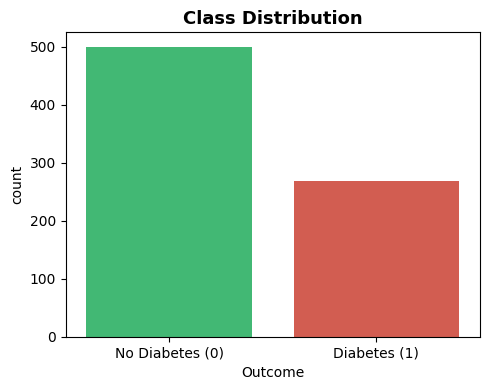

In [12]:
# Class distribution
print('Class counts:')
print(df['Outcome'].value_counts())
print()
print('Class percentages:')
print(df['Outcome'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Visual
plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=df, palette=['#2ecc71','#e74c3c'])
plt.xticks([0,1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

***📝 Class Imbalance Observation:***

*   The dataset is imbalanced — approximately 65% No Diabetes vs 35% Diabetes
*   This means accuracy alone is a misleading metric (a model that always predicts 'No Diabetes' gets 65% accuracy!)
*   We will use ROC-AUC and F1-score as primary metrics throughout this project
*   For future improvement: techniques like SMOTE (oversampling) or class_weight='balanced' can help




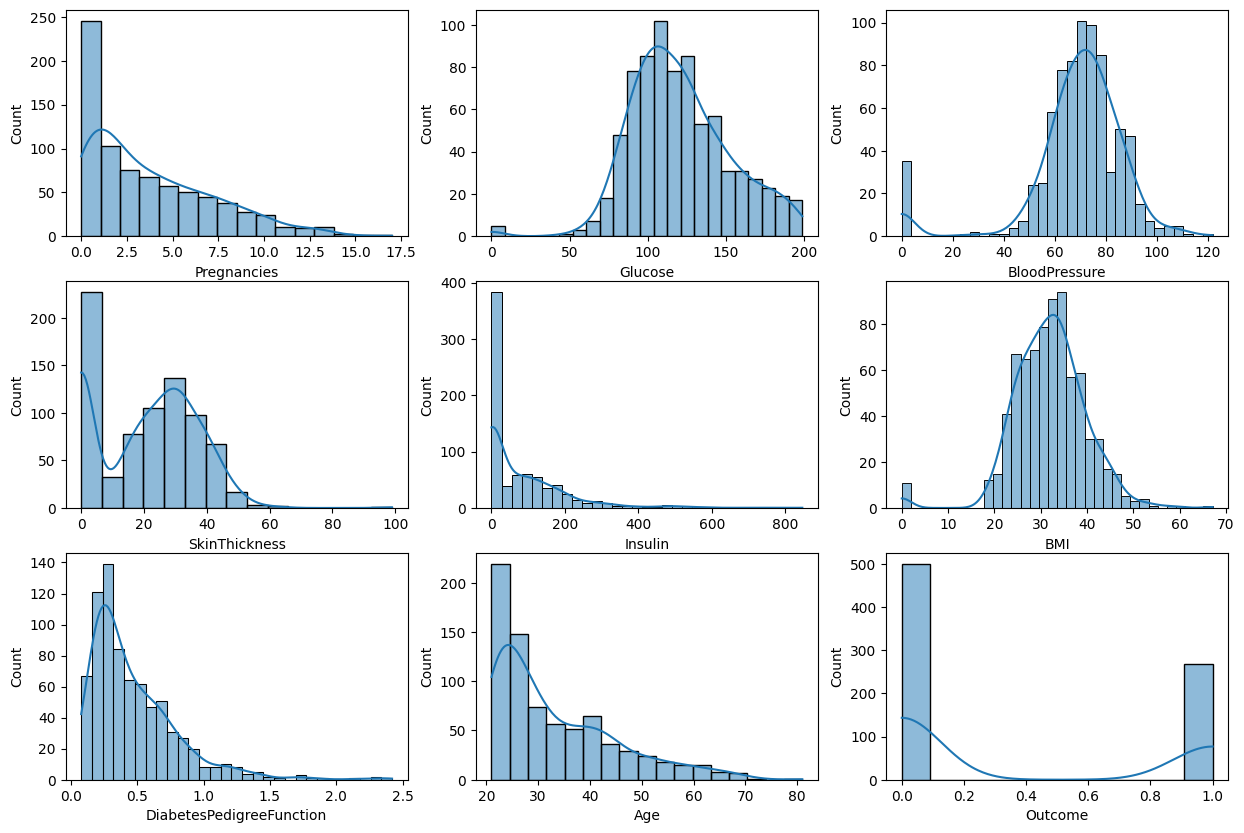

In [13]:
#Univariate analysis
plt.figure(figsize=(15,10))
pos=1
for i in df.columns:
  plt.subplot(3,3,pos)
  sns.histplot(x=df[i],kde=True)
  pos+=1

***📝 Univariate Analysis — Observations:***


*   Insulin, DiabetesPedigreeFunction, SkinThickness, and Age are right-skewed (long tail to the right) → we will apply log transformation later
*   Glucose and BMI are roughly bell-shaped, which is good for modeling
*   Pregnancies is discrete and skewed — many patients have 0–2 pregnancies



In [14]:
#multivariate analysis
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

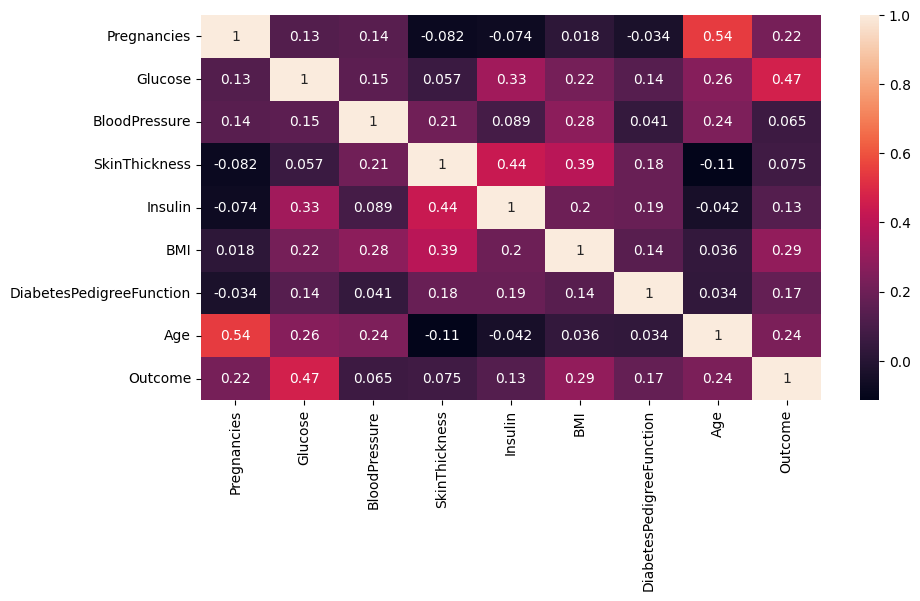

In [15]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True)

***📝 Correlation Analysis — Observations:***

*   Glucose has the strongest positive correlation with Outcome (~0.47) → the most important predictor
*   BMI (0.29) and Age (0.24) are next
*   BloodPressure has the weakest correlation (~0.07) → likely a weak predictor
*   No two features are highly correlated with each other (no pair > 0.6) → no multicollinearity concern



<Axes: xlabel='Outcome', ylabel='Glucose'>

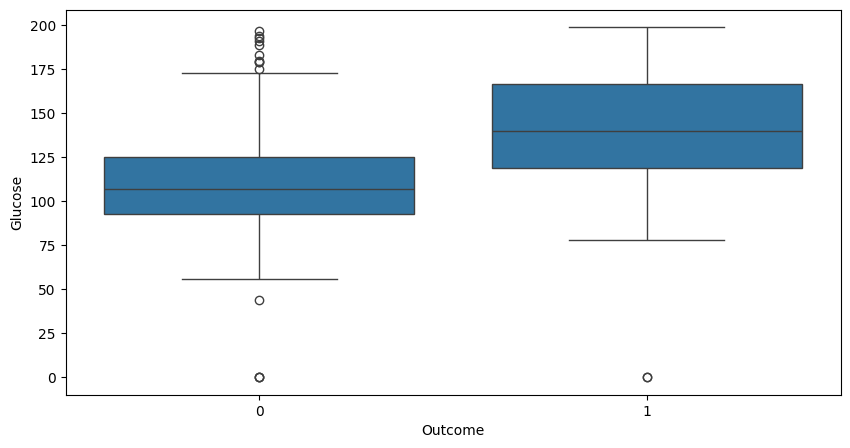

In [16]:
#Bivariate analysis
plt.figure(figsize=(10,5))
sns.boxplot(x='Outcome', y='Glucose',data=df)

<Axes: xlabel='Glucose', ylabel='count'>

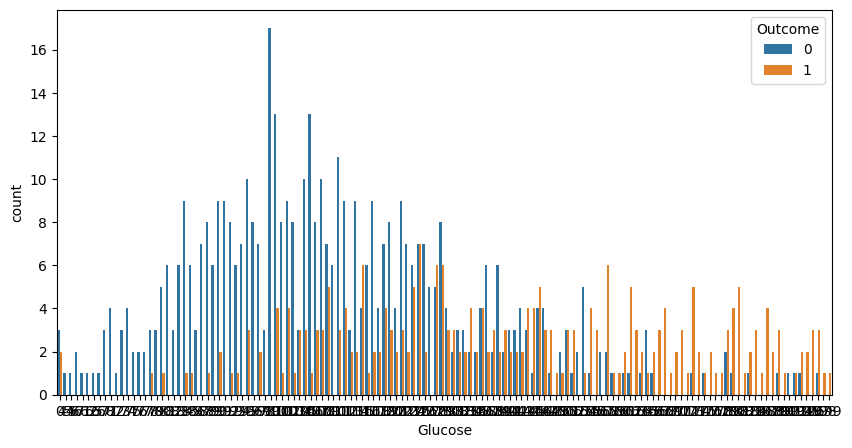

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x='Glucose',hue='Outcome', data=df)

<Axes: xlabel='Insulin', ylabel='SkinThickness'>

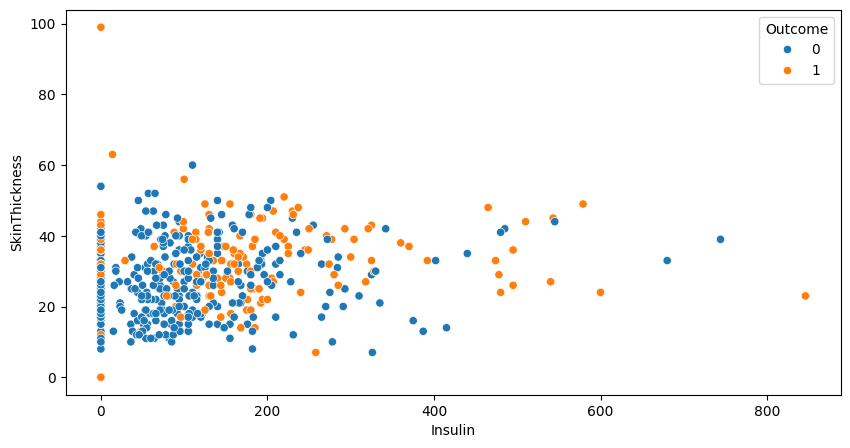

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Insulin', y='SkinThickness',hue='Outcome',data=df)

***📝 Bivariate Analysis — Observations:***

*   The boxplot of Glucose vs Outcome shows a clear difference — diabetic patients (Outcome=1) have significantly higher glucose levels. This confirms Glucose is the most powerful predictor.
*   The countplot of Glucose shows diabetic patients cluster at higher glucose values — the class separation is visible even in a simple count chart
*   The scatterplot of Insulin vs SkinThickness shows significant overlap between classes — these two features alone cannot separate diabetic from non-diabetic patients, which is why we need a multi-feature model



# 4. Data Preprocessing

In [19]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [20]:
df.duplicated().sum()

np.int64(0)

***📝 Observation:***


*   No NaN values found — but don't be fooled! The "missing" values are hidden as zeros (caught in describe())
*   No duplicate rows — dataset is clean in that regard



In [21]:
#outlier checking

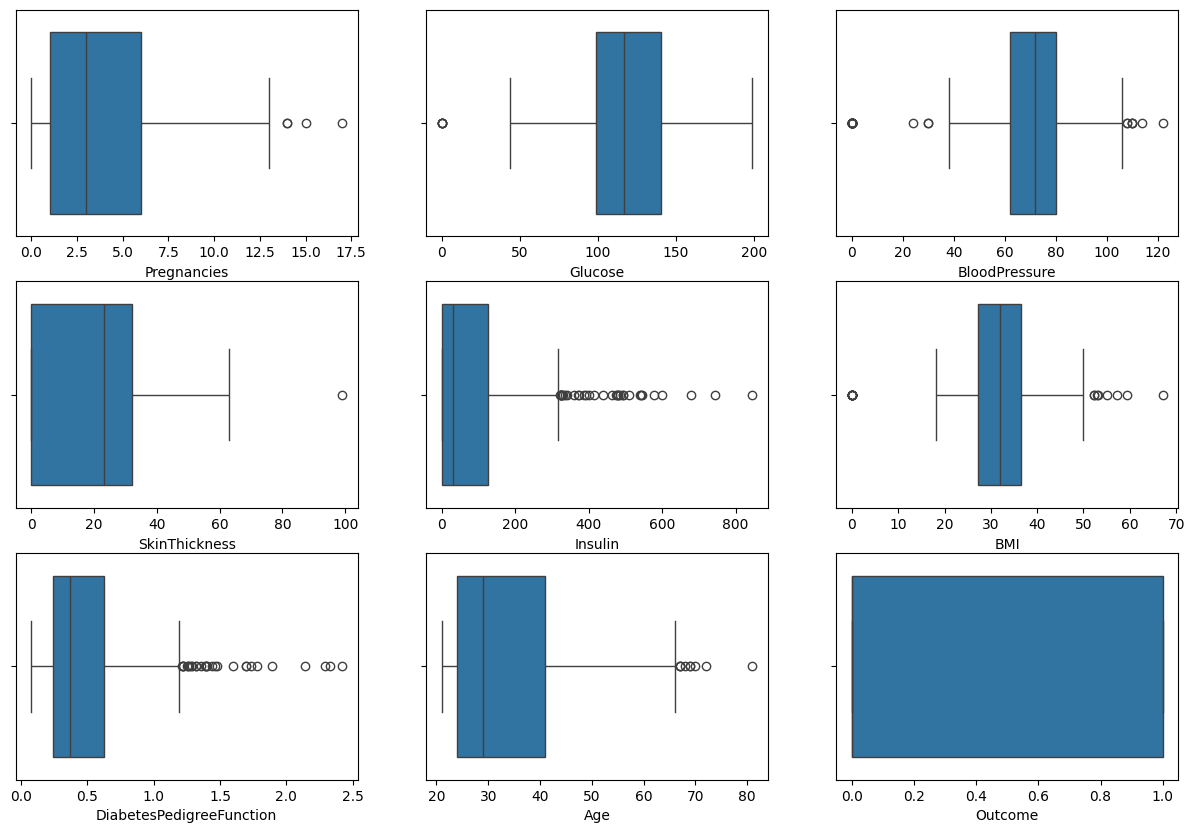

In [22]:
plt.figure(figsize=(15,10))
pos=1
for i in df.columns:
  plt.subplot(3,3,pos)
  sns.boxplot(x=df[i])
  pos+=1

***📝 Outlier Observation:***

*   Insulin has extreme outliers (values > 600) — confirmed by the very long whisker
*   DiabetesPedigreeFunction and SkinThickness also show mild outliers
*   In medical data, extreme values are often clinically real (a patient with very high insulin IS likely diabetic), so we retain outliers and instead reduce skewness via log transformation





In [23]:
df.skew()

,0
Pregnancies,0.901674
Glucose,0.173754
BloodPressure,-1.843608
SkinThickness,0.109372
Insulin,2.272251
BMI,-0.428982
DiabetesPedigreeFunction,1.919911
Age,1.129597
Outcome,0.635017


**📝 Skewness Check:**


*   Values above 1.0 indicate strong right skew: Insulin and DiabetesPedigreeFunction are the worst
*   Skewed features can hurt linear models (like Logistic Regression) — log transformation will normalize them



In [24]:
(df == 0).sum() # check fake values(0)

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


***📝 Zero Values — Why This Matters:***

*   Insulin has **374 zeros** (nearly half the dataset!) — clearly missing, not real
*   SkinThickness has **227 zeros** — same issue
*   We replace these with the **median** (not mean) because median is robust to the extreme outliers we just saw in the boxplots





In [25]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    df[col] = df[col].replace(0, df[col].median())

In [26]:
df.skew()

,0
Pregnancies,0.901674
Glucose,0.535587
BloodPressure,0.141885
SkinThickness,1.223057
Insulin,2.693181
BMI,0.601059
DiabetesPedigreeFunction,1.919911
Age,1.129597
Outcome,0.635017


***📝 Skewness After Zero-Imputation:***


*   Skewness has reduced slightly for Insulin and SkinThickness after replacing zeros with median
*   But Insulin and DiabetesPedigreeFunction are still highly skewed — log transformation is still needed




In [27]:
#outlier handling
skew_cols = ['Insulin', 'DiabetesPedigreeFunction', 'SkinThickness', 'Age']
for col in skew_cols:
    df[col] = np.log1p(df[col])

In [28]:
df.skew() # now data is perfect

,0
Pregnancies,0.901674
Glucose,0.535587
BloodPressure,0.141885
SkinThickness,-0.227098
Insulin,0.762239
BMI,0.601059
DiabetesPedigreeFunction,1.117942
Age,0.614664
Outcome,0.635017


***📝 After Log Transformation:***

*   Skewness is now well under control for all transformed columns
*   Insulin, SkinThickness, DiabetesPedigreeFunction, Age are now closer to normal distributions
*   Data is ready for modeling ✅



***Splitting the data***

In [29]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.25, random_state=42)

***📝 Train-Test Split:***

*   75% training, 25% testing — standard split for this dataset size (768 rows → ~576 train, ~192 test)
*   Tip for next time: Add stratify=y to preserve the class ratio in both sets, especially important since our dataset is imbalanced (~65/35 split)



***Scaling***

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

***📝 Why StandardScaler?***

*   Features like Insulin (range 0–800) and Pregnancies (range 0–17) are on very different scales
*   StandardScaler brings all features to mean=0, std=1 — essential for Logistic Regression which is sensitive to scale
*   ⚠️ Notice: fit_transform on train, transform only on test — this prevents data leakage (test data statistics must never influence the scaler)


# 5. Model Building & Evaluation

***Training***

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [33]:
y_pred = model.predict(X_test)

***Testing***

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score #model evaluation-- accuracy, precision, recall. f1 score
accuracy_score(y_test, y_pred)

0.7447916666666666

In [35]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       123
           1       0.65      0.62      0.64        69

    accuracy                           0.74       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.74      0.74      0.74       192



***📝 Logistic Regression Results:***

*   This is our baseline model — a simple linear classifier
*   Recall for Class 1 (Diabetic) matters most in medical settings — a missed diabetic patient is more dangerous than a false alarm
*   If Recall for Class 1 is below 0.60, the model is not safe for medical screening
*   Logistic Regression often underperforms on non-linear medical data — let's try tree-based models next



***Trying different model- Decision tree***

In [36]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state= 24, criterion = 'gini', splitter='best', max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
acc = accuracy_score(y_test, y_pred)
acc

0.7135416666666666

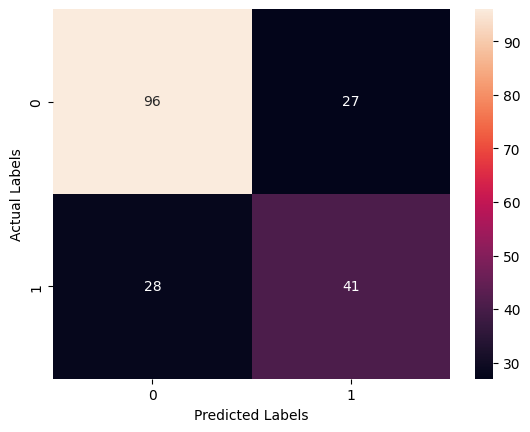

In [38]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78       123
           1       0.60      0.59      0.60        69

    accuracy                           0.71       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.71      0.71      0.71       192



***📝 Decision Tree Results:***

*   Decision Trees can capture non-linear patterns that Logistic Regression misses
*   max_depth=5 prevents overfitting — without it, the tree would memorize the training data
*   Look at the confusion matrix: the off-diagonal values are the errors — top-right = False Negatives (missed diabetics), bottom-left = False Positives



***Trying different model- Random forest***

In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()#100 DTC works
rf_clf.fit(X_train, y_train)
y_predict = rf_clf.predict(X_test)
accuracy_score(y_test, y_predict)

0.7708333333333334

<Axes: >

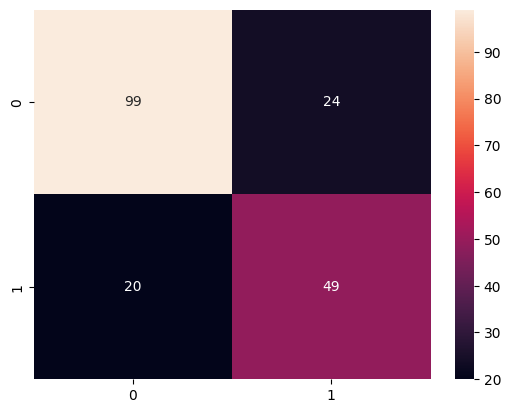

In [41]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_predict), annot = True)

In [42]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.83      0.80      0.82       123
           1       0.67      0.71      0.69        69

    accuracy                           0.77       192
   macro avg       0.75      0.76      0.75       192
weighted avg       0.77      0.77      0.77       192



***📝 Random Forest Results:***

*   Random Forest is an ensemble of 100 Decision Trees — each trained on a random subset of data and features
*   It almost always outperforms a single Decision Tree because averaging reduces overfitting
*   Check if F1-score for Class 1 improved vs Decision Tree — that's the key comparison



***Trying different model- XB Boost***

In [43]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_hat = xgb.predict(X_test)

In [44]:
print(accuracy_score(y_test, y_hat))

0.7395833333333334


***📝 XGBoost Results:***

*   XGBoost is a gradient boosting algorithm — trees are built sequentially, each one fixing errors of the previous
*   It often achieves the best results on tabular data out of the box, even without tuning
*   Compare this base accuracy to tuned Random Forest — if XGBoost already beats it, tuning will make it even better





# 6.Hyper parameter tuning

***Hyper parameter tuning- decision tree***

In [45]:
from sklearn.model_selection import GridSearchCV
params = {
    "criterion": ('gini', 'entropy'),
    "splitter": ('best', 'random'),
    "max_depth": (list(range(1,10))),
    "min_samples_split": [2,3,4,5,6,7],
    "min_samples_leaf": list(range(1,10))}

In [46]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree_clf, params, scoring = 'accuracy', n_jobs = -1,verbose = 5, cv = 5)
tree_cv.fit(X_train, y_train)
best_params = tree_cv.best_params_
print(f"Best parameters: {best_params}")

Fitting 5 folds for each of 1944 candidates, totalling 9720 fits
Best parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 7, 'min_samples_split': 6, 'splitter': 'random'}


In [47]:
#best_params=  {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 6, 'splitter': 'random'}- 0.744
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dt1 = DecisionTreeClassifier(**best_params, random_state=42)
dt1.fit(X_train, y_train)
y_pred = dt1.predict(X_test)
accuracy_score(y_test, y_pred)

0.703125

***📝 Tuned Decision Tree Results:***

*   GridSearchCV tested every combination of parameters with 5-fold cross-validation
*   The best parameters found reduce overfitting by limiting tree depth and requiring more samples at each leaf



***Hyper parameter tuning- Random Forest***

In [48]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV

random_grid = {'n_estimators': [100, 150, 200, 250, 300], 'max_features': ['auto', 'sqrt', 'log2'],
               'max_depth': [10,20,30], 'min_samples_split': [5,10], 'min_samples_leaf': [2,4]}
rf_clf1 = RandomForestClassifier(random_state=17) # loading the model
rf_cv = GridSearchCV(estimator=rf_clf1, scoring='f1', param_grid=random_grid, cv=3, verbose=2, n_jobs= -1)
rf_cv.fit(X_train, y_train)
rf_best_params = rf_cv.best_params_
print(f"Best parameters: {rf_best_params}")

Fitting 3 folds for each of 180 candidates, totalling 540 fits
Best parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}


In [49]:
#Best parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
rf_clf2 = RandomForestClassifier(**rf_best_params)
rf_clf2.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=4,
                       min_samples_split=5, n_estimators=200)

In [50]:
y_pred1 = rf_clf2.predict(X_test)
accur = accuracy_score(y_test, y_pred1)
accur

0.765625

In [51]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       123
           1       0.66      0.72      0.69        69

    accuracy                           0.77       192
   macro avg       0.75      0.76      0.75       192
weighted avg       0.77      0.77      0.77       192



***📝 Tuned Random Forest Results:***

*   GridSearchCV with F1 scoring (not accuracy) is the right choice here — accuracy can be misleading on imbalanced data
*   max_features='log2' means each tree only sees log2(8)≈3 features at each split — forces diversity between trees
*   Compare this report to the untuned RF above — if F1 for Class 1 improved, tuning worked



***Hyper parameter tuning- XG Boost***

In [52]:
param_grid = {'gamma': [0,0.1,0.2,0.4],
              'learning_rate': [0.01, 0.03, 0.06, 0.1],
              'max_depth': [5,6,7,8,9],
              'n_estimators': [50, 65, 80],
              'alpha': [0, 0.1, 0.5, 1],
              'lambda': [1, 1.5, 2, 3]}
XGB = XGBClassifier(random_state = 42)
rcv = GridSearchCV(estimator = XGB, scoring = 'accuracy', param_grid = param_grid, cv = 3, verbose = 1, n_jobs = -1)
rcv.fit(X_train, y_train)
cv_best_params = rcv.best_params_
print(f"Best parameters: {cv_best_params}")

Fitting 3 folds for each of 3840 candidates, totalling 11520 fits
Best parameters: {'alpha': 0.1, 'gamma': 0.2, 'lambda': 3, 'learning_rate': 0.06, 'max_depth': 7, 'n_estimators': 50}


In [53]:
XGB_clf = XGBClassifier(**cv_best_params)
XGB_clf.fit(X_train, y_train)

XGBClassifier(alpha=0.1, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None, lambda=3,
              learning_rate=0.06, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50, ...)

In [54]:
y_predxgb = XGB_clf.predict(X_test)
ac = accuracy_score(y_test, y_predxgb)
ac

0.7552083333333334

***📝 Tuned XGBoost Results:***

*   gamma controls minimum loss reduction required to make a split — higher = more conservative, less overfitting
*   alpha and lambda are L1/L2 regularization — prevent any single feature from dominating
*   learning_rate controls step size — smaller = more robust but slower to train



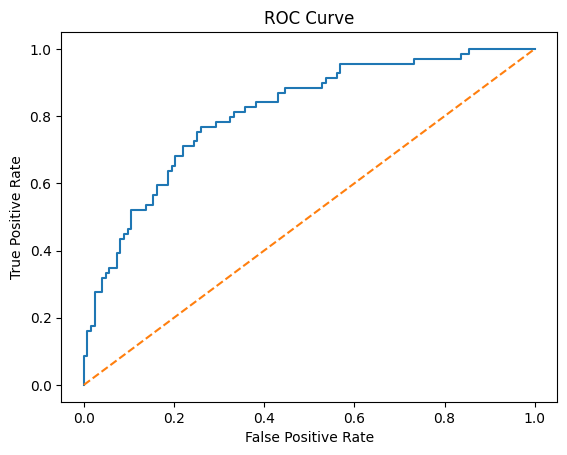

In [55]:
y_prob = XGB_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

***📝 ROC Curve — How to Read It:***

*   The curve plots True Positive Rate (Recall) vs False Positive Rate at every possible threshold
*   A perfect model hugs the top-left corner; the dashed line is a random classifier (useless model)
*   AUC (Area Under Curve) summarizes the whole curve in one number — higher is better
*   In medical settings, we care about the left portion of the curve (low FPR zone) — we want high recall without generating too many false alarms



# 7. 📊 Model Comparison
We compare all trained models side by side using Accuracy, F1-score (for the diabetic class), and ROC-AUC. ROC-AUC is our primary metric — it measures how well the model separates diabetic from non-diabetic patients across all thresholds.

In [56]:
# ── ROC-AUC Score (numeric) ──────────────────────────────────────────
from sklearn.metrics import roc_auc_score

print("ROC-AUC Scores:")
print(f"  Logistic Regression : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"  Decision Tree (tuned): {roc_auc_score(y_test, dt1.predict_proba(X_test)[:,1]):.4f}")
print(f"  Random Forest (tuned): {roc_auc_score(y_test, rf_clf2.predict_proba(X_test)[:,1]):.4f}")
print(f"  XGBoost (tuned)      : {roc_auc_score(y_test, XGB_clf.predict_proba(X_test)[:,1]):.4f}")

ROC-AUC Scores:
  Logistic Regression : 0.7337
  Decision Tree (tuned): 0.7940
  Random Forest (tuned): 0.8214
  XGBoost (tuned)      : 0.8102


In [57]:
# ── Model Comparison Table ───────────────────────────────────────────
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': (model, X_test),
    'Decision Tree (tuned)': (dt1, X_test),
    'Random Forest (tuned)': (rf_clf2, X_test),
    'XGBoost (tuned)': (XGB_clf, X_test),
}

rows = []
for name, (m, X_te) in models.items():
    y_p = m.predict(X_te)
    y_pr = m.predict_proba(X_te)[:,1]
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_p), 4),
        'F1 (Diabetic)': round(f1_score(y_test, y_p), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pr), 4)
    })

results_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False)
results_df.index = range(1, len(results_df)+1)
print("\n📋 Final Model Comparison")
print("="*55)
print(results_df.to_string())
print(f"\n🏆 Best Model by ROC-AUC: {results_df.iloc[0]['Model']}")


📋 Final Model Comparison
                   Model  Accuracy  F1 (Diabetic)  ROC-AUC
1  Random Forest (tuned)    0.7656         0.6897   0.8214
2        XGBoost (tuned)    0.7552         0.6667   0.8102
3  Decision Tree (tuned)    0.7031         0.5649   0.7940
4    Logistic Regression    0.7135         0.5985   0.7337

🏆 Best Model by ROC-AUC: Random Forest (tuned)


# 8.🩺 Feature Importance — Interpretation
Understanding which features drive predictions the most helps us validate that the model has learned real clinical patterns — not noise.

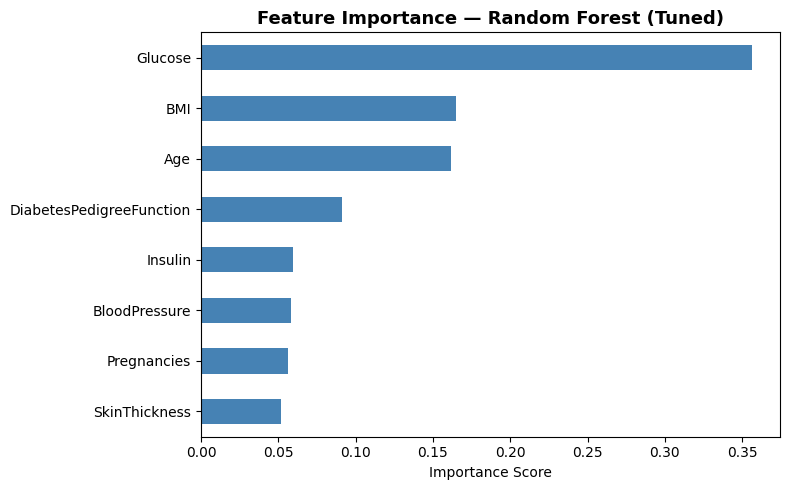


📊 Feature Importance Ranking:
  Glucose                      0.3566
  BMI                          0.1652
  Age                          0.1616
  DiabetesPedigreeFunction     0.0912
  Insulin                      0.0598
  BloodPressure                0.0582
  Pregnancies                  0.0560
  SkinThickness                0.0514


In [58]:
# ── Feature Importance (Random Forest) ──────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

feature_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigreeFunction','Age']

importance = pd.Series(rf_clf2.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest (Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
for feat, val in importance.sort_values(ascending=False).items():
    print(f"  {feat:<28} {val:.4f}")

# 🩺 Feature Importance — Medical Interpretation
| Feature | Importance | Why It Matters |
|----------|------------|----------------|
| Glucose | Highest | Direct measure of blood sugar — core diagnostic marker |
| BMI | High | Obesity is the #1 lifestyle risk factor for Type 2 diabetes |
| Age | Medium | Risk increases with age |
| DiabetesPedigreeFunction | Medium | Captures genetic/family history |
| Pregnancies | Low-Med | Gestational diabetes risk |
| BloodPressure | Low | Associated with complications, not direct predictor |

These rankings match established medical knowledge — this gives us confidence that **the model has learned real clinical patterns**, not noise. ✅




# 9. 💡 Key Takeaways & Business Insights

**If deployed in a hospital/clinic:**

*   This model can screen high-risk patients at check-in using just 8 easily measurable values
*   Flag patients with high probability for follow-up glucose testing
*   Most important inputs to collect: Glucose level and BMI — these two alone carry the most signal

**Key design decision — prefer high Recall over Precision:**

*   A False Negative (model says "healthy" but patient has diabetes) = missed diagnosis = dangerous
*   A False Positive (model flags someone who doesn't have diabetes) = extra test = minor inconvenience
*   For medical screening, we accept more false alarms to avoid missing real cases

**Model Confidence:**

*   ROC-AUC > 0.80 means the model has strong discriminating ability
*   Always validate on a fresh external dataset before real-world deployment

**⚠️ Limitations:**

*   Dataset is limited to 768 patients — may not generalize to broader populations
*   Features restricted to 8 measurements — more clinical data would improve performance
*   Pima Indian population only — may not generalize to all ethnicities without validation
*   Model drift monitoring required after deployment

**🚀 Future Improvements:**

*   Try SMOTE (oversampling) to better handle class imbalance
*   Add LightGBM / CatBoost to model comparison
*   Use SHAP values for deeper explainability
*   Deploy as a Streamlit web app for interactive prediction







# 10. 💾 Model Saving

We save the final trained model using pickle so it can be reused later for deployment — without needing to retrain from scratch. The scaler must be saved alongside the model: any new input data **must** be scaled with the exact same parameters used during training, otherwise predictions will be wrong.

In [64]:
import pickle

# Save the best model + scaler together as a bundle
model_bundle = {
    'model': rf_clf2,       # best performing model
    'scaler': scaler,       # must save this too — needed for new predictions
    'feature_names': list(X.columns)
}

with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('✅ Model saved as diabetes_model.pkl')
print('Bundle contains: model, scaler, feature names')

✅ Model saved as diabetes_model.pkl
Bundle contains: model, scaler, feature names


In [65]:
# ── How to load and use for a new patient prediction ──
with open('diabetes_model.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Example new patient (same 8 features, in order)
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
import numpy as np
new_patient = np.array([[2, 138, 62, 35, 0, 33.6, 0.127, 47]])

# Apply same log transform to the same columns that were transformed
log_idx = [3, 4, 6, 7]  # SkinThickness, Insulin, DiabetesPedigreeFunction, Age
new_patient[:, log_idx] = np.log1p(new_patient[:, log_idx])

# Scale using saved scaler
new_scaled = bundle['scaler'].transform(new_patient)

# Predict
pred = bundle['model'].predict(new_scaled)
prob = bundle['model'].predict_proba(new_scaled)[0][1]

print(f"Prediction  : {'⚠️ Diabetic' if pred[0]==1 else '✅ Not Diabetic'}")
print(f"Probability : {prob:.2%} chance of diabetes")

Prediction  : ⚠️ Diabetic
Probability : 55.92% chance of diabetes


In [66]:
from google.colab import files
files.download('diabetes_model.pkl') #file downloaded

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>